#Khởi tạo và đọc dữ liệu

In [ ]:
!pip install gdown

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import gdown

In [ ]:
# Đọc dữ liệu
file_id = "1LvdD1CysRb8uPxp-zpBtGY2k6T7dMm63"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "Silver_Data.csv", quiet=False)

df = pd.read_csv("Silver_Data.csv")

Downloading...
From: https://drive.google.com/uc?id=1LvdD1CysRb8uPxp-zpBtGY2k6T7dMm63
To: /content/Silver_Data.csv
100%|██████████| 3.38M/3.38M [00:00<00:00, 20.8MB/s]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ten                  16270 non-null  object 
 1   dia_chi              16270 non-null  object 
 2   diem_danh_gia        16270 non-null  float64
 3   so_luong_danh_gia    16270 non-null  float64
 4   vi_tri               16270 non-null  float64
 5   dich_vu              16270 non-null  float64
 6   dang_gia_tien        16270 non-null  float64
 7   co_so_vat_chat       16270 non-null  float64
 8   do_sach_se           16270 non-null  float64
 9   bep                  16270 non-null  int64  
 10  bua_sang             16270 non-null  int64  
 11  san_gon              16270 non-null  int64  
 12  may_giat             16270 non-null  int64  
 13  dua_don_san_bay      16270 non-null  int64  
 14  phong_tap            16270 non-null  int64  
 15  don_phong_hang_ngay  16270 non-null 

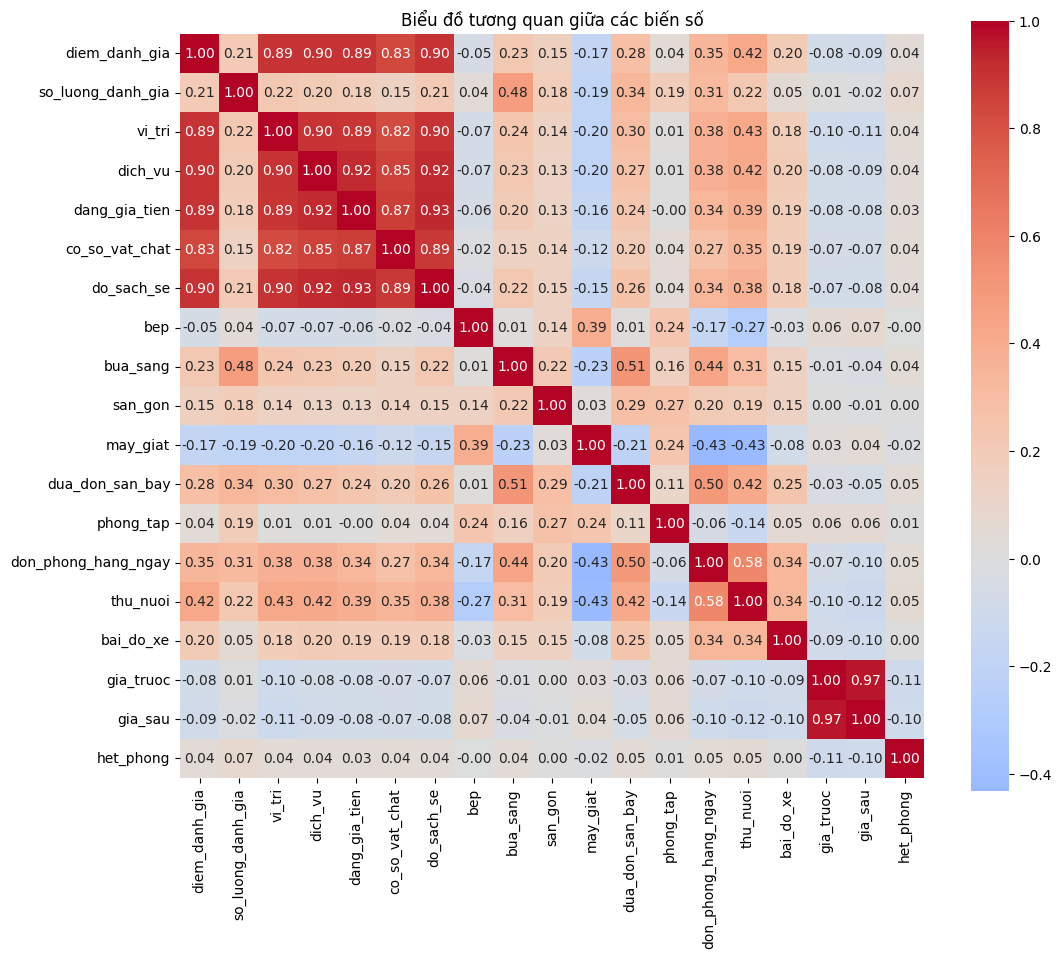

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
corr = df_numeric.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Biểu đồ tương quan giữa các biến số")
plt.show()


- Các biến vi_tri, dich_vu, dang_gia_tien, co_so_vat_chat, và do_sach_se có tương quan rất mạnh (≥ 0.83) với diem_danh_gia vì đây là các yếu tố ảnh hưởng trực tiếp đến sự hài lòng của khách hàng.

- Các biến tiện ích như may_giat hay bep có tương quan âm hoặc gần như không đáng kể, cho thấy ít ảnh hưởng hoặc thậm chí gây giảm điểm đánh giá.

- Nhìn chung, các yếu tố về trải nghiệm dịch vụ có ảnh hưởng cao hơn tiện ích vật lý.

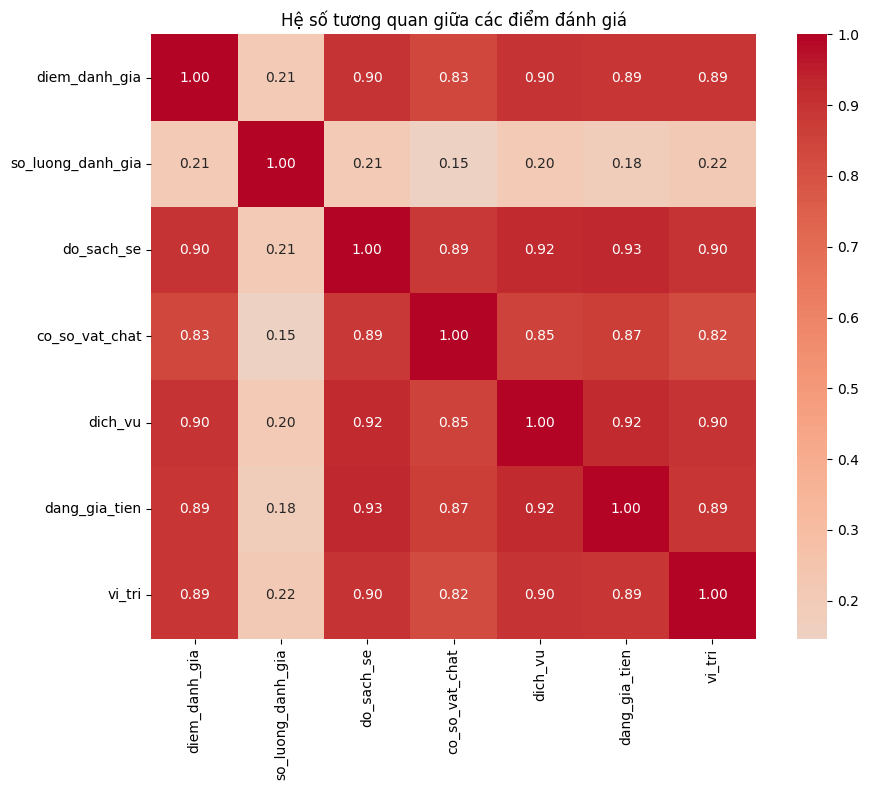

In [ ]:
# Lọc các cột liên quan đến đánh giá
cols_to_corr = [
    'diem_danh_gia',
    'so_luong_danh_gia',
    'do_sach_se',
    'co_so_vat_chat',
    'dich_vu',
    'dang_gia_tien',
    'vi_tri'
]

# Giữ lại các cột cần tính tương quan
df_corr = df[cols_to_corr].select_dtypes(include=[np.number])

# Tính toán và vẽ heatmap
corr = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, center=0)
plt.title("Hệ số tương quan giữa các điểm đánh giá")
plt.tight_layout()
plt.show()

#Biến đầu ra là diem_danh_gia nên sẽ chọn các biến tương quan mạnh với diem_danh_gia: vi_tri, dich_vu, dang_gia_tien, co_so_vat_chat, do_sach_se

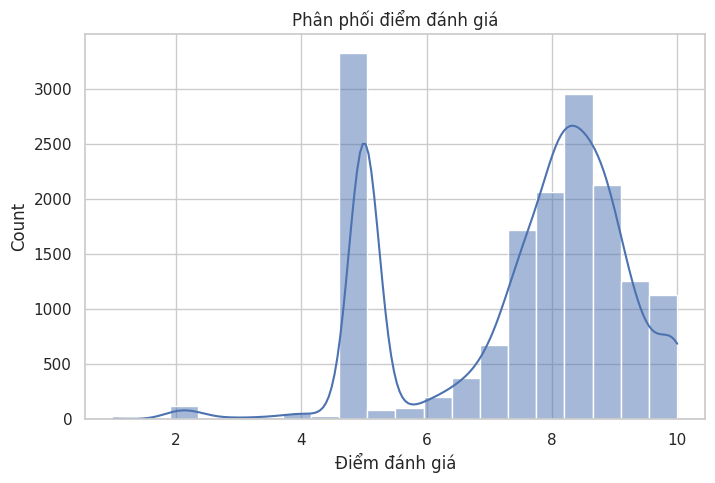

In [ ]:
# Đặt style cho biểu đồ
sns.set(style="whitegrid")

# 1. Phân phối điểm đánh giá
plt.figure(figsize=(8,5))
sns.histplot(df["diem_danh_gia"], bins=20, kde=True)
plt.title("Phân phối điểm đánh giá")
plt.xlabel("Điểm đánh giá")
plt.show()

Điểm đánh giá có 2 phân cụm rõ rệt: một cụm tập trung ở khoảng 5 (Do tiền xử lý dữ liệu) và một cụm ở khoảng 8–9 (cao).

Phân phối lệch phải nhẹ, chứng tỏ đa phần khách sạn có đánh giá tốt.

Sự phân tầng này phản ánh mức độ phân hóa chất lượng dịch vụ rõ rệt giữa các nhóm khách sạn.

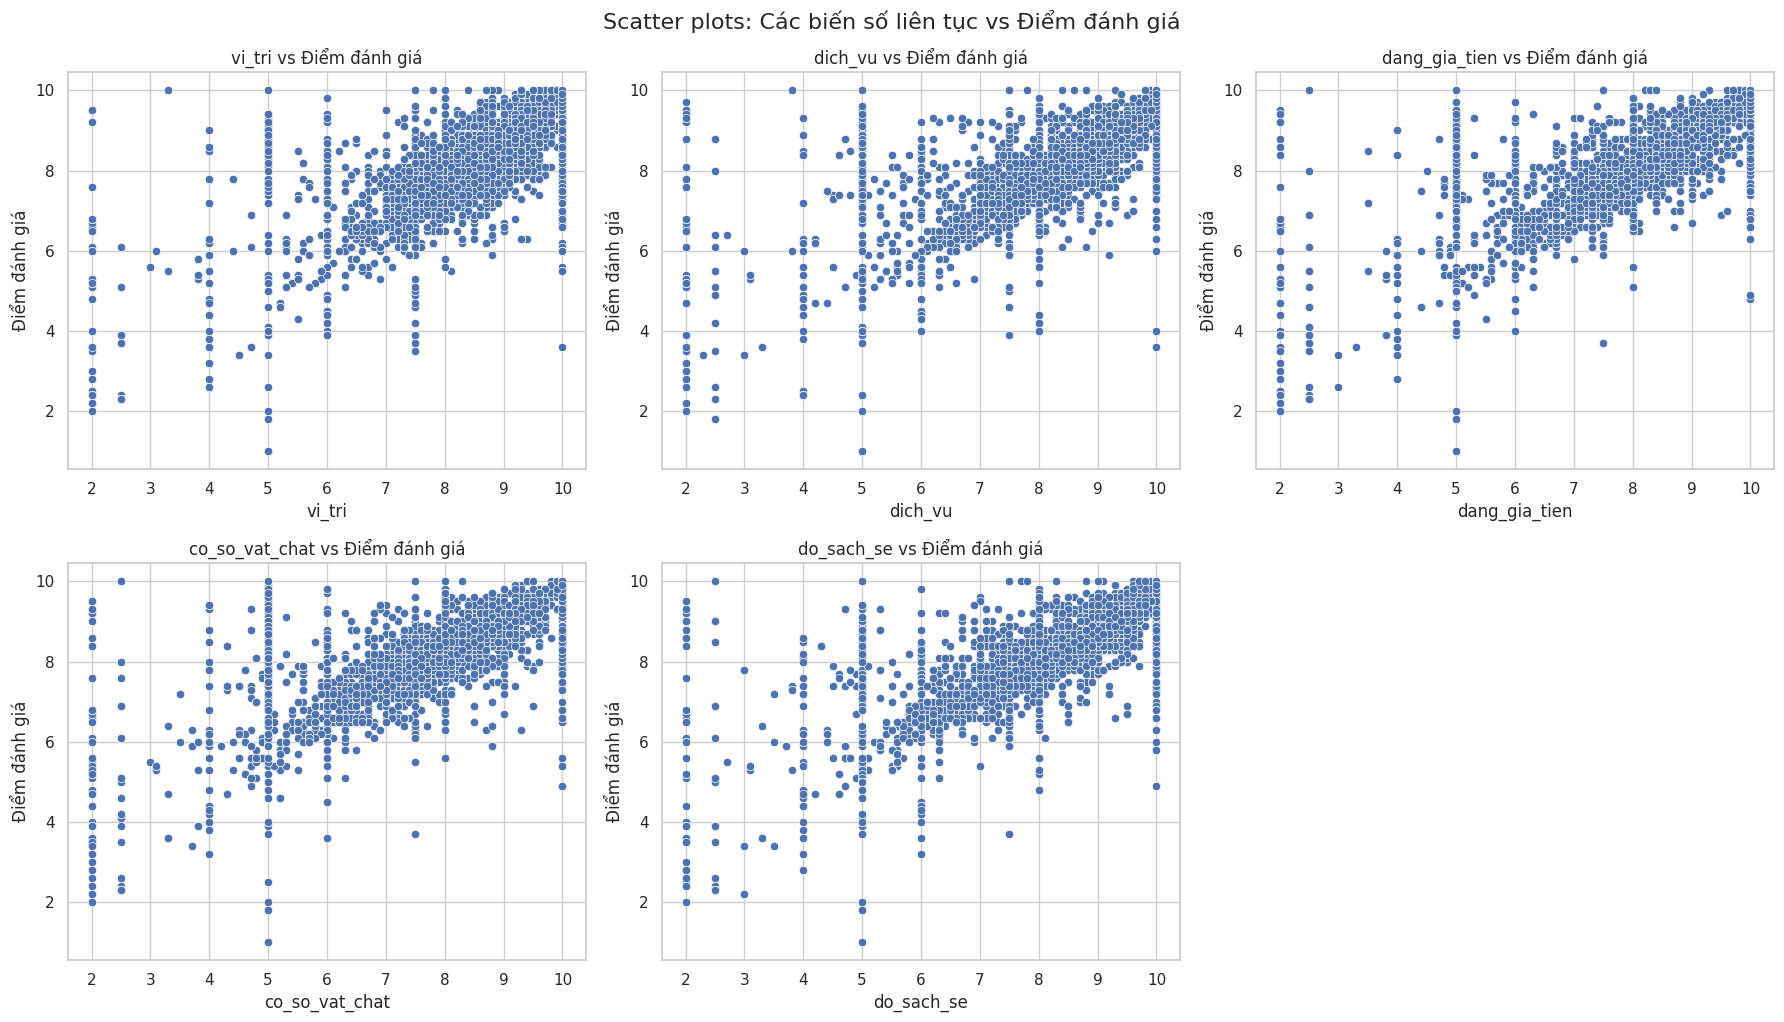

In [ ]:
# 2. Scatter plot giữa điểm đánh giá và các biến số liên tục
features_cont = [ "vi_tri", "dich_vu", "dang_gia_tien", "co_so_vat_chat", "do_sach_se"]

plt.figure(figsize=(18, 10))
for idx, feature in enumerate(features_cont):
    plt.subplot(2, 3, idx+1)
    sns.scatterplot(data=df, x=feature, y="diem_danh_gia")
    plt.title(f"{feature} vs Điểm đánh giá")
    plt.xlabel(feature)
    plt.ylabel("Điểm đánh giá")
plt.tight_layout()
plt.suptitle("Scatter plots: Các biến số liên tục vs Điểm đánh giá", fontsize=16, y=1.02)
plt.show()

Tất cả các biến liên tục như vi_tri, dich_vu, co_so_vat_chat, do_sach_se... đều cho thấy mối tương quan tuyến tính dương rõ ràng với điểm đánh giá.

Nghĩa là: dịch vụ càng tốt, vệ sinh sạch sẽ, vị trí thuận lợi → điểm đánh giá càng cao.

Biểu đồ này xác thực trực quan kết quả từ heatmap và củng cố vai trò của các yếu tố trải nghiệm.

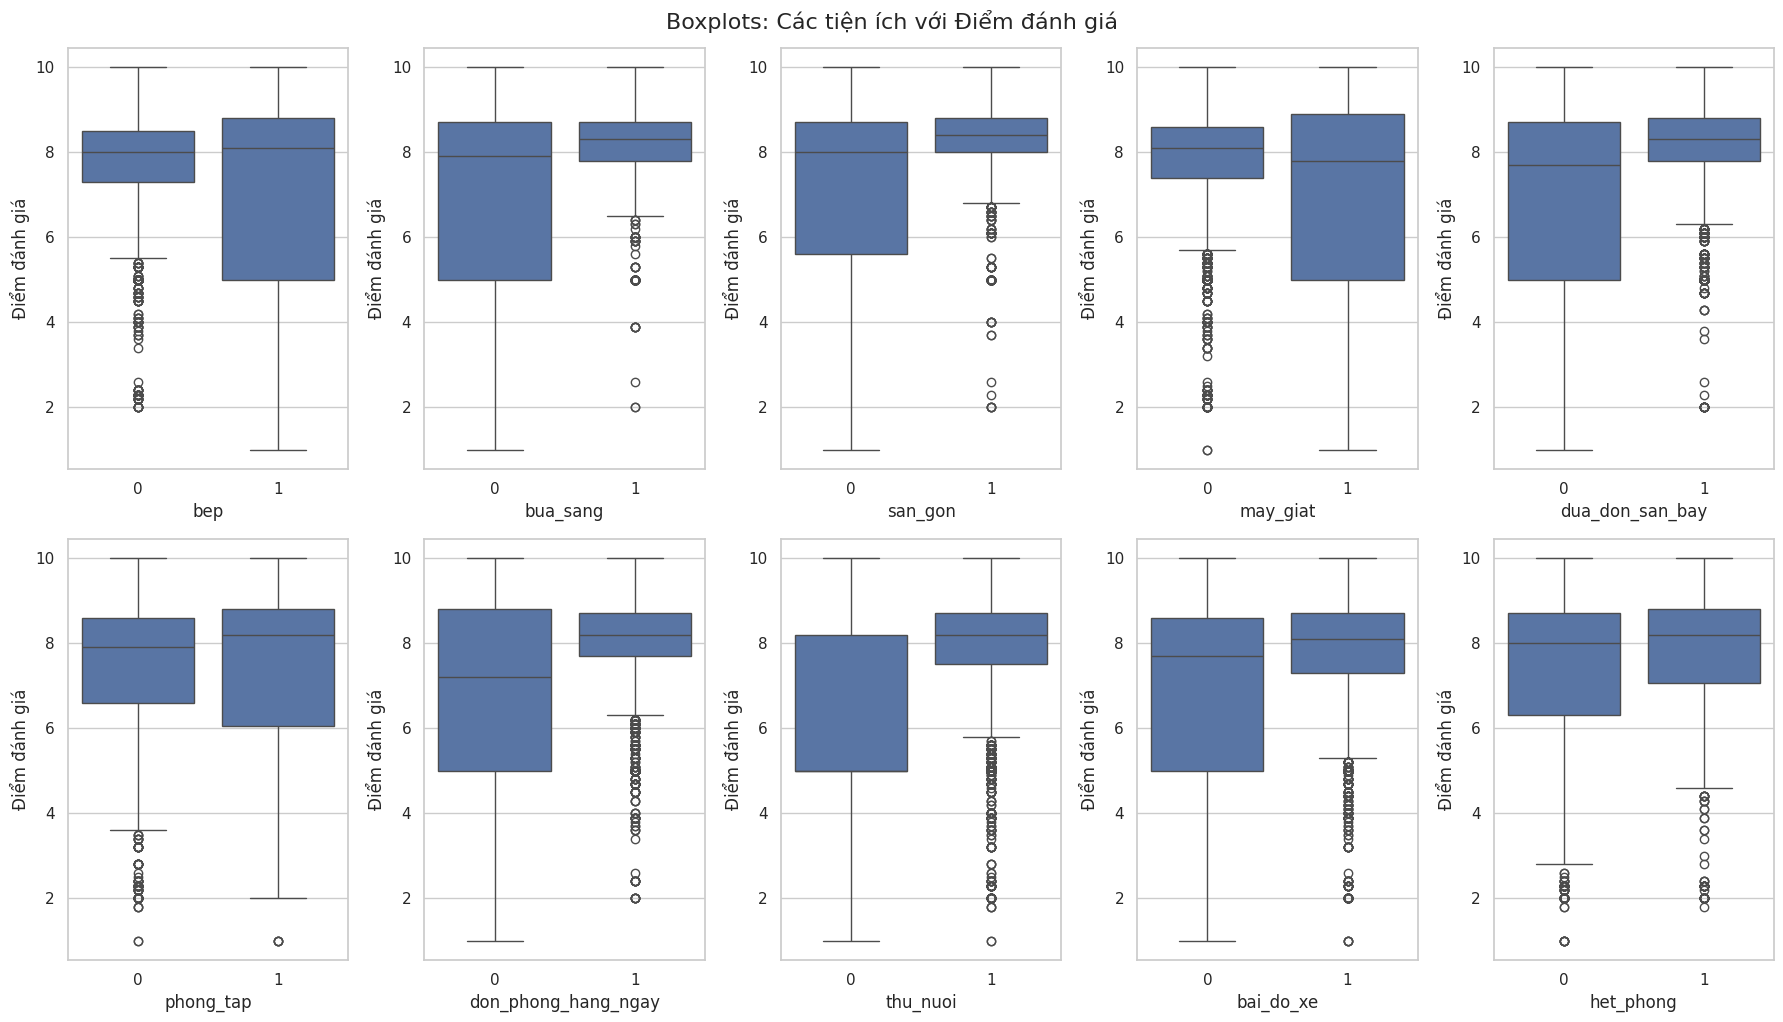

In [ ]:
# 3. Boxplot giữa điểm đánh giá và các biến nhị phân
features_binary = ["bep", "bua_sang", "san_gon", "may_giat", "dua_don_san_bay",
                   "phong_tap", "don_phong_hang_ngay", "thu_nuoi", "bai_do_xe", "het_phong"]

plt.figure(figsize=(18, 10))
for idx, feature in enumerate(features_binary):
    plt.subplot(2,5, idx+1)
    sns.boxplot(data=df, x=feature, y="diem_danh_gia")
    plt.xlabel(feature)
    plt.ylabel("Điểm đánh giá")
plt.tight_layout()
plt.suptitle("Boxplots: Các tiện ích với Điểm đánh giá", fontsize=16, y=1.02)
plt.show()


Các tiện ích như bua_sang, dua_don_san_bay, và don_phong_hang_ngay có sự khác biệt rõ rệt giữa nhóm có và không có tiện ích → ảnh hưởng tích cực đến điểm đánh giá.

Một số tiện ích như bep, may_giat, san_gon có vẻ không tạo sự khác biệt đáng kể hoặc có nhiều điểm đánh giá thấp khi có tiện ích → có thể do nhu cầu khách hàng không cao.

Gợi ý: các tiện ích nên được đầu tư chọn lọc theo nhu cầu thực tế thay vì trang bị đại trà.

In [ ]:
# 4. Trung bình điểm đánh giá theo khu vực
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="vi_tri_map", y="diem_danh_gia", estimator='mean', ci=None)
plt.xticks(rotation=45)
plt.title("Trung bình điểm đánh giá theo khu vực")
plt.show()

Khách sạn ở TP.HCM có điểm đánh giá nhỉnh hơn một chút so với khu vực BMT.

Sự khác biệt không lớn nhưng có thể do khách hàng ở đô thị có yêu cầu cao hơn, hoặc chất lượng dịch vụ có cải tiến rõ rệt tại TP.HCM.

Cần phân tích sâu thêm nếu muốn đánh giá mức độ chênh lệch đáng kể về địa lý.

In [ ]:
binary_features = ["bep", "bua_sang", "san_gon", "may_giat", "dua_don_san_bay",
                   "phong_tap", "don_phong_hang_ngay", "thu_nuoi", "bai_do_xe", "het_phong"]

plt.figure(figsize=(10, 6))
df[binary_features].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Tần suất các tiện ích khách sạn")
plt.ylabel("Số lượng khách sạn có tiện ích")
plt.xticks(rotation=45)
plt.show()

Khách sạn thường ưu tiên các tiện ích thiết yếu và phổ biến như cho phép nuôi thú cưng, có bếp, bãi đỗ xe

Các tiện ích cao cấp hoặc đặc thù như sân gôn, hẹn phòng ít được cung cấp hơn.

Điều này phản ánh nhu cầu thực tế của khách hàng và xu hướng đầu tư của các khách sạn